# Flight Trend & Optimization Analyzer

## 1. Project Overview

This project fetches **real-time global flight data** from the [OpenSky Network API](https://opensky-network.org) and performs data analysis using Object-Oriented Programming (OOP) in Python.

**Core objectives:**
1. Fetch live flight data via REST API
2. Analyze country distribution and airline activity
3. Study velocity and altitude patterns
4. Filter and export data for further use


---
## 2. Environment Setup & Module Import


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.flight_logic import FlightDataAnalyzer, LiveFlightAPI

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("[INFO] Environment initialized. Modules and visualization libraries loaded.")


[INFO] Environment initialized. Modules and visualization libraries loaded.


---
## 3. Load Live Data from OpenSky Network API

We use the `LiveFlightAPI` child class (inherits from `FlightDataAnalyzer`) to fetch real-time flight data.
The endpoint `https://opensky-network.org/api/states/all` delivers a dynamic **JSON response**:
- The root object contains `time` (Unix timestamp) and `states` (a 2D array of airborne aircraft state vectors).
- Because `states` contains an array of raw values rather than named keys, our ingestion logic parses the official index positions:
  - `flight[0]`: **icao24** (unique 24-bit transponder hex ID)
  - `flight[1]`: **callsign** (8-character flight identifier)
  - `flight[2]`: **country** (aircraft country of registration)
  - `flight[5]`: **longitude** & `flight[6]`: **latitude** (WGS-84 coordinates)
  - `flight[7]`: **altitude** (barometric altitude in meters)
  - `flight[9]`: **velocity** (ground speed in m/s)
  - `flight[10]`: **heading** (direction of motion in degrees)

The parsed records are converted into a `pandas.DataFrame` and cleaned of missing transponder records.


In [2]:
# Initialize API loader and fetch live flight data
live_api = LiveFlightAPI()

if live_api.fetch_live_flights(limit=500):
    print(f"[SUCCESS] Loaded {len(live_api.df)} live flights from OpenSky Network")
    print(f"Columns: {list(live_api.df.columns)}")
    display(live_api.df.head(10))
else:
    print("[ERROR] Failed to fetch data. Check network connection.")


[SUCCESS] Hamtade och validerade 500 flygningar fran OpenSky Network
[SUCCESS] Loaded 500 live flights from OpenSky Network
Columns: ['icao24', 'callsign', 'country', 'longitude', 'latitude', 'altitude', 'velocity', 'heading']


,icao24,callsign,country,longitude,latitude,altitude,velocity,heading
0,39de4f,TVF539X,France,28.0328,41.1157,2857.50,142.90,117.67
1,e8027e,LNE1457,Chile,-80.0954,25.4386,3032.76,152.66,158.45
2,e8027d,LPE2390,Chile,-74.8775,4.4080,11582.40,229.80,356.79
3,a1abea,N2069K,United States,-117.8400,47.5893,2849.88,77.53,243.60
4,39de4d,TVF43PN,France,-1.7182,42.7102,11887.20,239.06,207.28
5,aa9321,UAL983,United States,-76.0920,40.1383,5593.08,207.25,263.16
6,39de4c,TVF27SZ,France,5.6263,46.8695,11582.40,216.97,309.81
7,39de57,TVF73RQ,France,13.8017,56.1332,11887.20,247.98,37.58
8,c07d20,JZA543,Canada,-79.3193,43.6455,350.52,67.14,254.90
9,39de50,TVF13SR,France,2.6413,48.7712,1036.32,81.76,254.30


---
## 4. Feature 1: Country Distribution Analysis

Which countries have the most airborne flights right now?


=== Top 10 Countries by Live Flight Count ===
  United States: 268 flights
  Hungary: 28 flights
  Sweden: 24 flights
  Canada: 19 flights
  India: 19 flights
  Chile: 17 flights
  Brazil: 16 flights
  Austria: 14 flights
  France: 13 flights
  Mexico: 12 flights


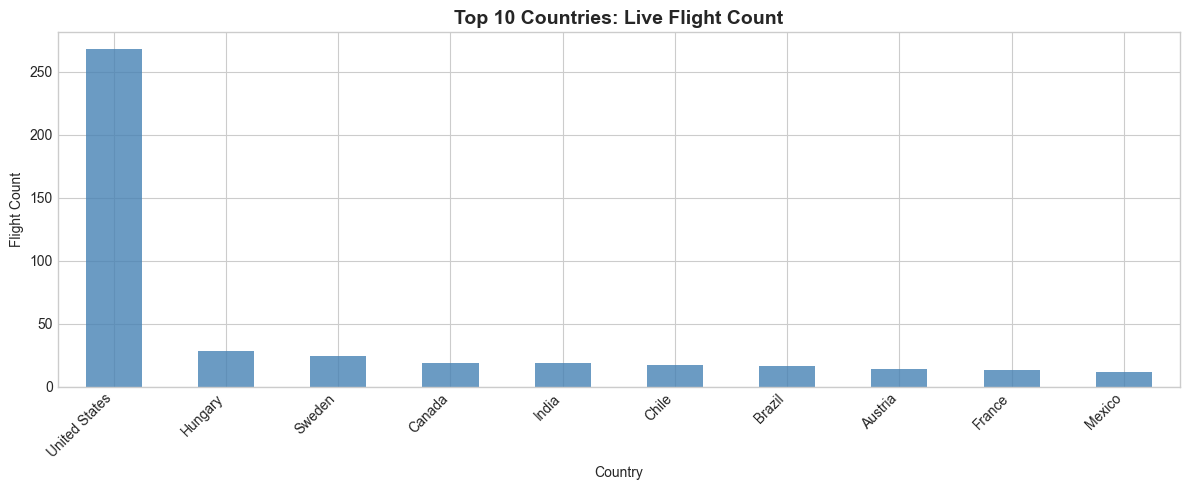

In [3]:
# Top 10 countries by live flight count
country_stats = live_api.df["country"].value_counts().head(10)

print("=== Top 10 Countries by Live Flight Count ===")
for country, count in country_stats.items():
    print(f"  {country}: {count} flights")

# Bar chart visualization
plt.figure(figsize=(12, 5))
country_stats.plot(kind="bar", color="steelblue", alpha=0.8)
plt.title("Top 10 Countries: Live Flight Count", fontsize=14, fontweight="bold")
plt.xlabel("Country")
plt.ylabel("Flight Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


---
## 5. Feature 2: Velocity & Altitude Analysis

Analyze flight speed and altitude patterns across countries.


In [4]:
# Compute velocity and altitude stats by country
valid_flights = live_api.df.dropna(subset=["velocity", "altitude"])

vel_stats = valid_flights.groupby("country").agg(
    flight_count=("icao24", "count"),
    avg_velocity=("velocity", "mean"),
    avg_altitude=("altitude", "mean"),
    max_velocity=("velocity", "max")
).reset_index()

vel_stats["avg_velocity"] = vel_stats["avg_velocity"].round(2)
vel_stats["avg_altitude"] = vel_stats["avg_altitude"].round(2)
vel_stats["max_velocity"] = vel_stats["max_velocity"].round(2)

top_vel = vel_stats.sort_values("flight_count", ascending=False).head(10)
print("=== Top 10 Countries: Velocity & Altitude Stats ===")
display(top_vel)


=== Top 10 Countries: Velocity & Altitude Stats ===


,country,flight_count,avg_velocity,avg_altitude,max_velocity
26,United States,249,144.79,5060.26,297.20
10,Hungary,28,219.63,9190.26,261.13
22,Sweden,23,221.72,10012.02,276.96
2,Brazil,16,153.31,6703.70,270.96
5,Chile,16,204.06,8121.02,275.53
12,India,15,199.38,8152.38,279.39
4,Canada,13,95.71,2904.98,223.99
7,France,13,180.54,7877.91,247.98
1,Austria,12,182.81,7454.90,259.53
14,Mexico,11,192.66,8143.70,244.69


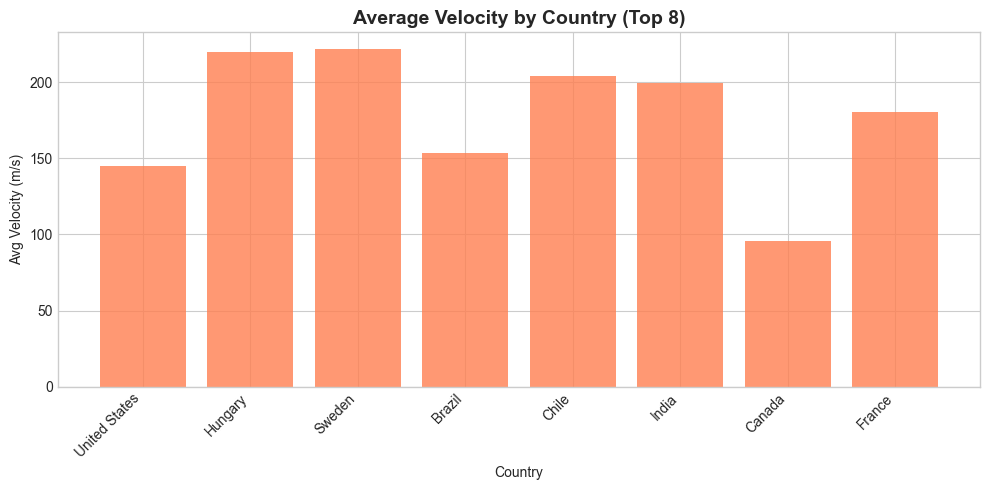

In [5]:
# Bar chart: average velocity by country
plt.figure(figsize=(10, 5))
top_countries = vel_stats.sort_values("flight_count", ascending=False).head(8)
plt.bar(top_countries["country"], top_countries["avg_velocity"], alpha=0.8, color="coral")
plt.title("Average Velocity by Country (Top 8)", fontsize=14, fontweight="bold")
plt.xlabel("Country")
plt.ylabel("Avg Velocity (m/s)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


---
## 6. For-loop: Detailed Flight Summary by Country

Use explicit `for` loops to iterate and print detailed stats for each top country.


In [6]:
# For-loop: print detailed summary for top countries
top_n = 5
country_counts = live_api.df["country"].value_counts().head(top_n)

print(f"\n{'='*60}")
print(f"  Top {top_n} Countries - Detailed Flight Summary")
print(f"{'='*60}")

for country, count in country_counts.items():
    subset = live_api.df[live_api.df["country"] == country]
    avg_vel = subset["velocity"].mean() if not subset["velocity"].isna().all() else 0
    avg_alt = subset["altitude"].mean() if not subset["altitude"].isna().all() else 0
    print(f"\nCountry: {country}")
    print(f"  Total flights: {count}")
    print(f"  Avg velocity: {avg_vel:.2f} m/s")
    print(f"  Avg altitude: {avg_alt:.2f} m")

print(f"\n{'='*60}")



  Top 5 Countries - Detailed Flight Summary

Country: United States
  Total flights: 268
  Avg velocity: 135.04 m/s
  Avg altitude: 5060.26 m

Country: Hungary
  Total flights: 28
  Avg velocity: 219.63 m/s
  Avg altitude: 9190.26 m

Country: Sweden
  Total flights: 24
  Avg velocity: 212.50 m/s
  Avg altitude: 10012.02 m

Country: Canada
  Total flights: 19
  Avg velocity: 66.30 m/s
  Avg altitude: 2904.98 m

Country: India
  Total flights: 19
  Avg velocity: 157.82 m/s
  Avg altitude: 8152.38 m



---
## 7. For-loop: Count Flights by Airline (Callsign)

Count how many flights each airline (callsign) currently has in the air.


In [7]:
# For-loop: count flights by callsign
airline_counts = {}
grouped = live_api.df.groupby("callsign")

for airline_name, group in grouped:
    if airline_name and airline_name.strip() and airline_name != "N/A":
        airline_counts[airline_name] = len(group)

sorted_airlines = dict(sorted(airline_counts.items(), key=lambda x: x[1], reverse=True))

print(f"\n{'='*60}")
print("  Top Airlines by Active Flight Count")
print(f"{'='*60}")

count = 0
for airline, flights in sorted_airlines.items():
    if count >= 10:
        break
    print(f"  {airline}: {flights} flights")
    count += 1

print(f"{'='*60}\n")



  Top Airlines by Active Flight Count
  AAL1829: 1 flights
  AAL1943: 1 flights
  AAL2242: 1 flights
  AAL2398: 1 flights
  AAL2586: 1 flights
  AAL2891: 1 flights
  AAL3312: 1 flights
  AAL332: 1 flights
  AAL753: 1 flights
  ACA147: 1 flights



---
## 8. Filter by Country

Filter live flights for a specific country and analyze distribution.


=== US Flights (268 total) ===


,icao24,callsign,country,longitude,latitude,altitude,velocity,heading
3,a1abea,N2069K,United States,-117.8400,47.5893,2849.88,77.53,243.60
5,aa9321,UAL983,United States,-76.0920,40.1383,5593.08,207.25,263.16
13,a3a568,N334HP,United States,-116.9641,32.8257,NaN,0.06,298.12
14,a53eef,UPS2838,United States,-89.6435,38.6620,9464.04,233.67,287.16
15,a0928d,XAA2554,United States,-88.6675,32.2272,10020.30,243.44,235.50
17,a5954e,N/A,United States,-107.8767,43.2982,10668.00,268.08,93.74
18,ae1fc0,MEANY14,United States,-85.7255,31.0745,822.96,72.88,300.55
20,a22233,CXK312,United States,-117.7872,34.0778,609.60,49.92,88.23
21,ad562a,TAI311,United States,-81.0829,22.2885,10652.76,234.70,185.66
22,a0f55d,N16093,United States,-92.7930,44.8526,800.10,31.96,273.69


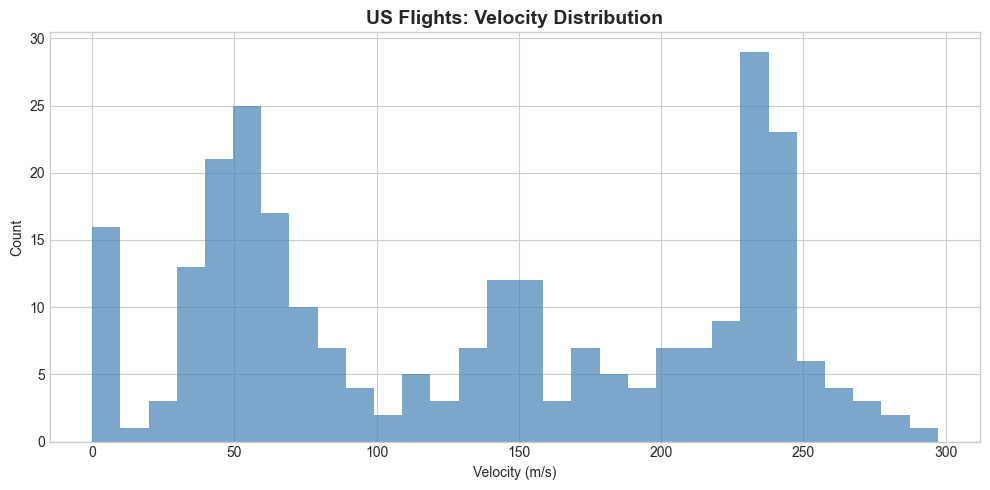

In [8]:
# Filter flights for United States
us_flights = live_api.get_flights_by_country("United States")

if not us_flights.empty:
    print(f"=== US Flights ({len(us_flights)} total) ===")
    display(us_flights.head(10))

    # Velocity distribution histogram
    plt.figure(figsize=(10, 5))
    us_flights["velocity"].dropna().hist(bins=30, color="steelblue", alpha=0.7)
    plt.title("US Flights: Velocity Distribution", fontsize=14, fontweight="bold")
    plt.xlabel("Velocity (m/s)")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
else:
    print("[WARNING] No US flights found in current data")


---
## 9. Data Export to CSV

Save the fetched live data to a CSV file for external use.


In [9]:
# Export live flight data to CSV
output_file = "live_flights_data.csv"
if live_api.export_cleaned_data(output_filepath=output_file):
    print(f"[SUCCESS] Exported {len(live_api.df)} records to '{output_file}'")
else:
    print("[ERROR] Export failed")


[SUCCESS] Exporterade 500 rader till 'live_flights_data.csv'
[SUCCESS] Exported 500 records to 'live_flights_data.csv'


In [10]:
live_api.show_project_summary()


[TEST] Stage 12: Project status & AI industry mapping verified.
  Mal 1 (Branschanalys) och Mal 5 (Certifikat) dokumenterade i README.md.
